In [ ]:
# loading all the required libraries
import pandas as pd
import numpy as np
import torch
from google.colab import files
from itertools import combinations
from collections import Counter
import networkx as nx
from sklearn.model_selection import train_test_split, KFold
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc)

In [ ]:
# mounting my drive to upload files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
drugs_se = pd.read_csv("/content/drive/MyDrive/drug_sideeffect_binary_matrix.csv") #reading drugs.tsv file , seperated by tab
drugs_se.head()

# keep only the binary side-effect columns as features
drugs_se = drugs_se.set_index("drug_name") # indexing the data frame using drug name
drugs_se = drugs_se.fillna(0).astype(int)
drugs_se.head()
print(f"drug in SE file: {drugs_se.index.nunique()}")
len(drugs_se.columns)

drug in SE file: 1020


5599

In [ ]:
drug_gene = pd.read_csv("/content/drive/MyDrive/intersection_DGIdb_mat.tsv", sep="\t") #reading drugs.tsv file , seperated by tab

# name the index 'drug_name'
drug_gene.index.name = 'drug_name'

# name the columns axis 'gene'
drug_gene.columns.name = 'gene'

print(f"drug in Gene file: {drug_gene.index.nunique()}")
drug_gene.head()
len(drug_gene.columns)

drug in Gene file: 777


2022

# **Defining Jaccards similarity Function**

In [ ]:
def jaccard_similarity_matrix(binary_df): # defining jaccard function
    A = binary_df.astype(int).to_numpy() # converting true/false values into integers 1/0 respectively to give numpy array
    inter = A @ A.T # calculates intersection count between a and at
    row_sum = A.sum(axis=1) # summing across column to get total count of 1 for each individual row
    union = row_sum[:, None] + row_sum[None, :] - inter # calculates union count using set formula

# calculates jaccard similarity
    sim = np.divide(inter, union,
                    out=np.zeros_like(inter, dtype=float), # initiates matrix filled with 0
                    where=union != 0) # ensuring division only where union is non-zero.

    np.fill_diagonal(sim, 1.0) # forces the diagonal of the matrix to 1. (exact same drug = 1)
    return pd.DataFrame(sim, index=binary_df.index, columns=binary_df.index) # returing to pandas df to preserve the rows and columns.

In [ ]:
# drug-drug similarity based on side-effect profiles
drugse_jaccard = jaccard_similarity_matrix(drugs_se)

# drug-drug similarity based on gene profiles
druggene_jaccard = jaccard_similarity_matrix(drug_gene)

In [ ]:
druggene_jaccard.head()

drug_name,ABACAVIR,ABIRATERONE,ACAMPROSATE,ACARBOSE,ACEBUTOLOL,ACETAMINOPHEN,ACETAZOLAMIDE,ACETYLCHOLINE,ACITRETIN,ACLIDINIUM,...,ZALEPLON,ZIDOVUDINE,ZILEUTON,ZIPRASIDONE,ZOLMITRIPTAN,ZOLPIDEM,ZONISAMIDE,ZOPICLONE,ZUCLOPENTHIXOL,PARECOXIB
drug_name,,,,,,,,,,,,,,,,,,,,,
ABACAVIR,1.0,0.0,0.0,0.0,0.0,0.0,0.043478,0.0,0.0,0.0,...,0.0,0.02439,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
ABIRATERONE,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.040000,0.0,0.076923,0.0,0.0,0.0,0.0
ACAMPROSATE,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
ACARBOSE,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
ACEBUTOLOL,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.045455,0.0,0.000000,0.0,0.0,0.0,0.0


In [ ]:
drugse_jaccard.head()

drug_name,2-FLUOROADENOSINE,5-METHYLTETRAHYDROFOLATE,99MTC-CIPROFLOXACIN,ABACAVIR,ABIRATERONE,ACAMPROSATE,ACARBOSE,ACEBUTOLOL,ACENOCOUMAROL,ACETAMINOPHEN,...,ZIDOVUDINE,ZILEUTON,ZINC,ZIPRASIDONE,ZOLEDRONATE,ZOLMITRIPTAN,ZOLPIDEM,ZONISAMIDE,ZOPICLONE,ZUCLOPENTHIXOL
drug_name,,,,,,,,,,,,,,,,,,,,,
2-FLUOROADENOSINE,1.000000,0.000000,0.156997,0.232653,0.139423,0.219136,0.077720,0.193548,0.071823,0.177258,...,0.239437,0.129534,0.000000,0.147303,0.202417,0.180055,0.157647,0.198347,0.154891,0.152597
5-METHYLTETRAHYDROFOLATE,0.000000,1.000000,0.000000,0.007353,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.005376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99MTC-CIPROFLOXACIN,0.156997,0.000000,1.000000,0.153025,0.093809,0.271012,0.055238,0.158845,0.032505,0.205527,...,0.220280,0.076336,0.001946,0.271570,0.237937,0.259380,0.277439,0.263754,0.231629,0.188136
ABACAVIR,0.232653,0.007353,0.153025,1.000000,0.169492,0.220736,0.105590,0.242991,0.071895,0.201493,...,0.282869,0.160494,0.007246,0.146930,0.218543,0.185629,0.175573,0.223565,0.172107,0.177536
ABIRATERONE,0.139423,0.000000,0.093809,0.169492,1.000000,0.145038,0.086538,0.168605,0.064516,0.142222,...,0.142222,0.149533,0.000000,0.098321,0.160920,0.125850,0.144092,0.122112,0.081967,0.135371


# Merging NA and NB using drug_gene similarity matrix on drugs and connected their associated gene and se with similarity score. Additionally, drugs showing similarity above 0.5 (threshold) is also added to the table.

* only keeps drugs passing the drug-gene similarity >= 0.3 threshold
* removes self-similarity
* uses common drugs only
* no duplication



In [ ]:
# removing axis names (drug_name/gene/se) to avoid duplications.
druggene_jaccard.index.name = None
druggene_jaccard.columns.name = None

drugse_jaccard.index.name = None
drugse_jaccard.columns.name = None

drug_gene.index.name = None
drug_gene.columns.name = None

drugs_se.index.name = None
drugs_se.columns.name = None

# keeping only common drugs which is present across all provided df
common_drugs = (
    druggene_jaccard.index # keeping drug gene jaccard as base df
    .intersection(drugse_jaccard.index) # interacting all below df at same drug
    .intersection(drug_gene.index)
    .intersection(drugs_se.index))

# Filter matrices
dg_sim = druggene_jaccard.loc[common_drugs, common_drugs] # trims both sim matrices, containig only common drugs for both row and columns
se_sim = drugse_jaccard.loc[common_drugs, common_drugs]

# creating final table and keeping drugs which passes threshhold of >= 0.3 in drug gene similarity matrix
rows = [] # initiating empty list

for drug in dg_sim.index:

    # removing self similarities and storing it in gene scores
    gene_scores = dg_sim.loc[drug].drop(labels=[drug], errors='ignore')

    # keep only similarity >= 0.3
    gene_scores = gene_scores[gene_scores >= 0.3]

    # skip drugs not passing threshold
    if len(gene_scores) == 0: #  if no other drug met the 0.3 threshod, it skips the entire loop and moves to next drug.
        continue

    # Checks the drug gene matrix for current drug and returns a list of gene where value is 1
    associated_genes = drug_gene.columns[drug_gene.loc[drug] == 1].tolist() # look up function

    # Checks the drug se matrix for current drug and returns a list of se where value is 1
    associated_side_effects = drugs_se.columns[drugs_se.loc[drug] == 1].tolist()

    # using gene score two separate lists are created one for the names of similar drugs and one for corresponding sim
    similar_gene_drugs = gene_scores.index.tolist() # stores name
    gene_similarity_scores = gene_scores.values.tolist() # stores score

    # se similarity scores
    se_scores = []

    for sim_drug in similar_gene_drugs:  # for each drug in similar_gene_drugs
      if sim_drug in se_sim.columns:
        se_score = se_sim.loc[drug, sim_drug] # loop up for corresponding se similarity score relative to drug in the se_sim

      else:
          se_score = np.nan

      se_scores.append(se_score) # append score and drug to se_score

   # storing a data, by constructing dictionary
    rows.append({
        'drug_name': drug,
        'similar_drugs': similar_gene_drugs,
        'drug_gene_similarity_scores': gene_similarity_scores,
        'drug_se_similarity_scores': se_scores,
        'associated_genes': associated_genes,
        'associated_side_effects': associated_side_effects
    })

# Converting dictionary into single pandas data frame
common_df = pd.DataFrame(rows)
print("\nFinal shape:")
print(common_df.shape)
common_df.head() # saves drug name, similar drug, assocaited genes and se


Final shape:
(536, 6)


,drug_name,similar_drugs,drug_gene_similarity_scores,drug_se_similarity_scores,associated_genes,associated_side_effects
0,ACAMPROSATE,[MEMANTINE],[0.3333333333333333],[0.3150684931506849],"[GRIN2B, GRIN3A, GRM5]","[ABDOMINAL DISTENSION, ABDOMINAL PAIN, ABNORMA..."
1,ACARBOSE,[MIGLITOL],[0.42857142857142855],[0.4772727272727273],"[AMY2A, GAA, LPL, MGA, MGAM, SI, SLC2A4]","[ABDOMINAL PAIN, ANGIOPATHY, CONSTIPATION, DER..."
2,ACEBUTOLOL,"[BETAXOLOL, BISOPROLOL, BRETYLIUM, CARTEOLOL, ...","[0.3333333333333333, 0.3333333333333333, 0.5, ...","[0.3187919463087248, 0.3779527559055118, 0.176...","[ADRB1, TG]","[ABDOMINAL PAIN, ABNORMAL DREAMS, ABNORMAL VIS..."
3,ACETAZOLAMIDE,"[BRINZOLAMIDE, METHAZOLAMIDE]","[0.38461538461538464, 0.375]","[0.09917355371900827, 0.5833333333333334]","[AQP1, AQP4, CA1, CA12, CA14, CA2, CA3, CA4, C...","[AGITATION, AGRANULOCYTOSIS, ANAPHYLACTIC SHOC..."
4,ACETYLCHOLINE,"[ACLIDINIUM, ATROPINE, BETHANECHOL, CARBACHOL,...","[0.8333333333333334, 0.38461538461538464, 0.83...","[0.0, 0.02843601895734597, 0.10526315789473684...","[ACE, CHRM1, CHRM2, CHRM3, CHRM4, CHRM5]","[BRADYCARDIA, CORNEAL DECOMPENSATION, CORNEAL ..."


In [ ]:
common_df[common_df["drug_name"] == "ACARBOSE"] # look up by using drug name

,drug_name,similar_drugs,drug_gene_similarity_scores,drug_se_similarity_scores,associated_genes,associated_side_effects
1,ACARBOSE,[MIGLITOL],[0.42857142857142855],[0.4772727272727273],"[AMY2A, GAA, LPL, MGA, MGAM, SI, SLC2A4]","[ABDOMINAL PAIN, ANGIOPATHY, CONSTIPATION, DER..."


Identifying drugs list using SE name directly.

In [ ]:
common_df[common_df["associated_side_effects"].apply(lambda x: "DERMATITIS" in str(x))]

,drug_name,similar_drugs,drug_gene_similarity_scores,drug_se_similarity_scores,associated_genes,associated_side_effects
0,ACAMPROSATE,[MEMANTINE],[0.3333333333333333],[0.3150684931506849],"[GRIN2B, GRIN3A, GRM5]","[ABDOMINAL DISTENSION, ABDOMINAL PAIN, ABNORMA..."
1,ACARBOSE,[MIGLITOL],[0.42857142857142855],[0.4772727272727273],"[AMY2A, GAA, LPL, MGA, MGAM, SI, SLC2A4]","[ABDOMINAL PAIN, ANGIOPATHY, CONSTIPATION, DER..."
2,ACEBUTOLOL,"[BETAXOLOL, BISOPROLOL, BRETYLIUM, CARTEOLOL, ...","[0.3333333333333333, 0.3333333333333333, 0.5, ...","[0.3187919463087248, 0.3779527559055118, 0.176...","[ADRB1, TG]","[ABDOMINAL PAIN, ABNORMAL DREAMS, ABNORMAL VIS..."
5,ACITRETIN,[ADAPALENE],[0.4375],[0.07523510971786834],"[GMNN, IL1B, KAT2A, KDM4A, MAPT, PLK1, RAPGEF4...","[ABDOMINAL PAIN, ACNE, ACUTE MYOCARDIAL INFARC..."
7,ADAPALENE,"[ACITRETIN, BEXAROTENE, TAZAROTENE]","[0.4375, 0.3076923076923077, 0.36363636363636365]","[0.07523510971786834, 0.06441717791411043, 0.2...","[RARA, RARB, RARG, RXRA, RXRB, RXRG, USP1]","[ABRASION NOS, ANGIOEDEMA, APPLICATION SITE PA..."
...,...,...,...,...,...,...
531,ZOLPIDEM,"[FLUNITRAZEPAM, GRISEOFULVIN, ZOPICLONE]","[0.38461538461538464, 0.3, 0.4]","[0.10810810810810811, 0.06784660766961652, 0.3...","[AR, CYP3A4, CYP3A5, GABRA1, GABRA2, GABRA3, G...","[ABDOMINAL DISCOMFORT, ABDOMINAL PAIN, ABDOMIN..."
532,ZONISAMIDE,"[ETHOTOIN, LAMOTRIGINE, LIDOCAINE, MEPHENYTOIN...","[0.43478260869565216, 0.32432432432432434, 0.3...","[0.06859205776173286, 0.4228187919463087, 0.15...","[AQP4, CA1, CA12, CA7, CACNA1G, CACNA1H, CACNA...","[ABDOMINAL PAIN, ABNORMAL DREAMS, ACCIDENTAL I..."
533,ZOPICLONE,"[BUTABARBITAL, FLUNITRAZEPAM, SECOBARBITAL, ZO...","[0.36363636363636365, 0.5555555555555556, 0.36...","[0.08487084870848709, 0.11439114391143912, 0.0...","[GABRA1, GABRA2, GABRA3, GABRA5, TSPO]","[ABDOMINAL PAIN, ABNORMAL BEHAVIOUR, ABNORMAL ..."
534,ZUCLOPENTHIXOL,"[FLUPHENAZINE, ISOXSUPRINE, KETOTIFEN, NAPHAZO...","[0.3333333333333333, 0.4, 0.3333333333333333, ...","[0.2170212765957447, 0.03553299492385787, 0.12...","[CYP1A2, CYP2D6, DRD1, DRD2, DRD5]","[ABDOMINAL PAIN, ABNORMAL DREAMS, ABNORMAL VIS..."


lambda x: "DERMATITIS" in str(x):
Defines an anonymous (inline) function that receives x (which is the list of side effects for a single drug in that row).

# **Building Drug Similarity graph from common df**
Use the thresholded common_df (where only drugs with at least one gene similarity ≥ 0.3 are kept in the graph and everything else is removed.) for the graph, not the full common_drugs intersection. **(NOT TO DELETE)**

In [ ]:
threshold_graph = nx.Graph() # creating an empty graph

seen_edges = set() # empty set initiated to track edges, preventing duplicate edges btw drug pairs

for _, row in common_df.iterrows(): # loops through each row in common_df, "_" helps to ignore the index
    drug = row["drug_name"]   # extracts drug, associated gene and se
    genes = row["associated_genes"]
    side_effects = row["associated_side_effects"]

    # Add the main drug node
    threshold_graph.add_node(
        drug, # primary drug node
        genes=genes, # adding metadata to drug
        side_effects=side_effects) # adding metadata to drug

    # Inner loop data = extracts 3 aligned lists contating similar drug name and their scores.
    similar_drugs = row["similar_drugs"]
    gene_scores = row["drug_gene_similarity_scores"]
    se_scores = row["drug_se_similarity_scores"]

    # using zip() to iterate through all three lists simultaneously.
    for sim_drug, gene_score, se_score in zip(similar_drugs, gene_scores, se_scores):

        # avoid duplicate undirected edges
        edge_key = tuple(sorted((drug, sim_drug))) #sorts the pair alphabetically, to ensure identical edge key
        if edge_key in seen_edges:
            continue
        seen_edges.add(edge_key) # if pair was already processed, it skips to the next iteration; otherwise it saves the pair in seen_edges

        # add similar drug node if not already present
        if sim_drug not in threshold_graph:
           threshold_graph.add_node(sim_drug)

        # creates an edge btw drug and sim drug, storing bth scores as edge attributes.
        threshold_graph.add_edge(
            drug,
            sim_drug,
            drug_gene_similarity=gene_score,
            drug_se_similarity=se_score
        )

print("Number of nodes:", threshold_graph.number_of_nodes())
print("Number of edges:", threshold_graph.number_of_edges())

Number of nodes: 536
Number of edges: 2416


COMMON DRUGS FROM BOTH THE SIMILARITY MATTRIX, HAVING THRESHOLD OF 0.5 DRUG-GENE SIMILARITY SCORE, AND THEIR ASSOCIATED SIDE-EFFECTS.
DRUGS ARE CONNECTED TO THE DRUGS WHICH SHOWS SIMILARITY. **(NOT TO DELETE)**

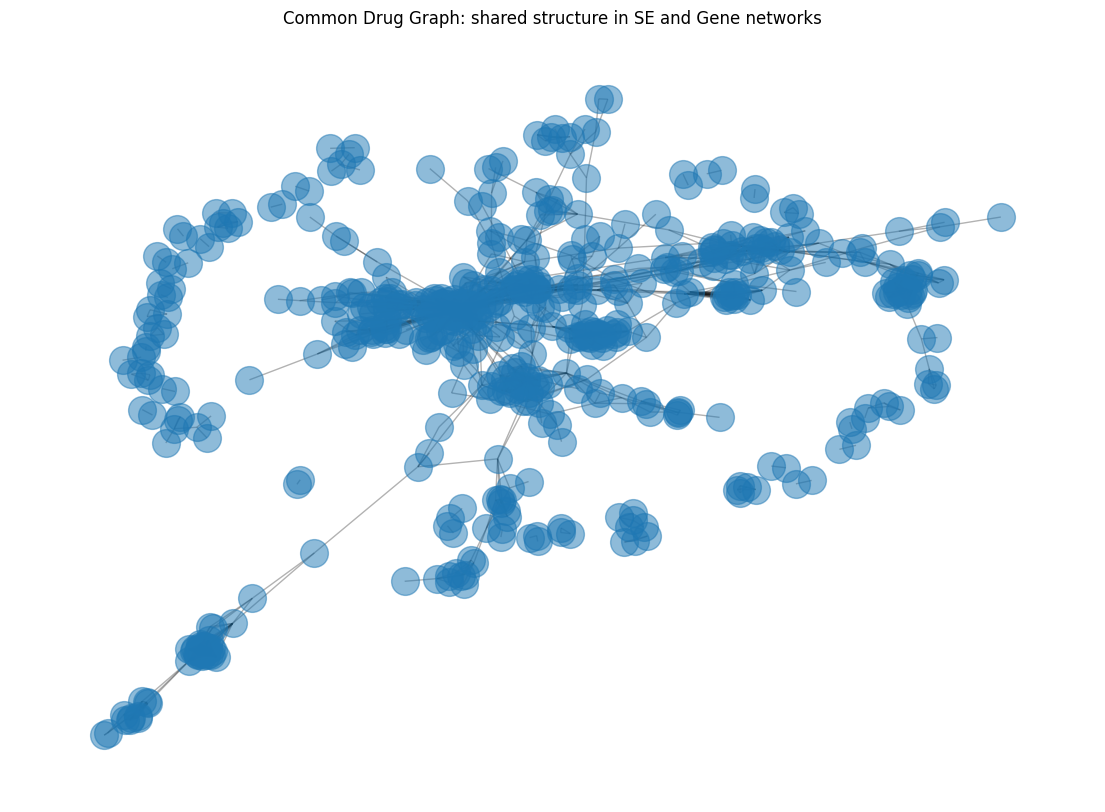

In [ ]:
plt.figure(figsize=(14, 10)) # 14 inches width and 10 inches height.
pos = nx.spring_layout(threshold_graph, k=0.5)

nx.draw_networkx_nodes(threshold_graph, pos, node_size=400, alpha=0.5)
nx.draw_networkx_edges(threshold_graph, pos, alpha=0.3)
#nx.draw_networkx_labels(threshold_graph, pos, font_size=8)

plt.title("Common Drug Graph: shared structure in SE and Gene networks")
plt.axis("off")
plt.show()

Here the common df has 563 drugs same as chunk 8, and not as above graph which shows only 308 after applying threshold for graphical purpose.

In [ ]:
# Extracting usable drugs

common_drugs = common_df["drug_name"].drop_duplicates().tolist()

common_drugs = ( # Keep only drugs present in both matrices
    pd.Index(common_drugs)
    .intersection(druggene_jaccard.index)
    .intersection(drugs_se.index)
    .tolist()
    )

print("Number of usable drugs:", len(common_drugs)) # printing count of validated drugs.


# Filters both datasets to only include common drugs
drug_gene_sim = druggene_jaccard.loc[common_drugs, common_drugs]
drug_se_matrix = drugs_se.loc[common_drugs]

W = drug_gene_sim.to_numpy(dtype=float) # converting gene-similarity df into numpy array W

print("Similarity matrix shape:", W.shape)
print("Side-effect matrix shape:", drug_se_matrix.shape)


# Harmonic Function

def harmonic_prediction(W, y, train_idx, eps=1e-6):
    """
    W: similarity matrix
    y: binary label vector for one side effect
    train_idx: indices of labeled training drugs
    """
    W = W.astype(float).copy() # copies matrix W and removes self-loops by setting the diagonal to 0.
    np.fill_diagonal(W, 0.0)

    d = W.sum(axis=1) # calculates the node degree vector d and;
    L = np.diag(d) - W # constructs the Graph Laplacian L = D-W

    all_idx = np.arange(W.shape[0])
    # identifies which node indices corresponds to test drugs
    unlabeled_idx = np.setdiff1d(all_idx, train_idx)

    # blocks laplacian matrix into submatrices L_uu (unlabeled-to-unlabeled);
    L_uu = L[np.ix_(unlabeled_idx, unlabeled_idx)]
    # and L_ul (unlabeled-to-labeled)
    L_ul = L[np.ix_(unlabeled_idx, train_idx)]

    f_u = np.linalg.solve( # linear algebra
        L_uu + eps * np.eye(L_uu.shape[0]), # .shape[0] Grabs number of rows of matrix L_uu, eye generates N x N identity matrix
        -L_ul @ y[train_idx]
    ) # solves the linear system LuuFu = -LulYl to propagate known labels across the network to unlabeled nodes.

    f = np.zeros(W.shape[0], dtype=float)
    f[train_idx] = y[train_idx]
    f[unlabeled_idx] = f_u
    return f    # combines known training labels Yl and predicted continuous scores fu into single vector

def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)


# 5-FOLD CROSS VALIDATION SPLIT ON DRUGS
kf = KFold(n_splits=5, shuffle=True, random_state=27)

results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(common_drugs), start=1):

    print(f"\nProcessing fold {fold}...")
    print("Train drugs:", len(train_idx), "Test drugs:", len(test_idx))

    for side_effect in drug_se_matrix.columns:

        y = drug_se_matrix[side_effect].to_numpy(dtype=float)

        y_train = y[train_idx]
        y_test = y[test_idx]

        if y_train.sum() == 0 or y_test.sum() == 0:
            continue

        if len(np.unique(y_test)) < 2:
            continue

        # harmonic prediction
        scores = harmonic_prediction(W, y, train_idx)

        y_score = scores[test_idx]
        y_score_norm = minmax_scale(y_score)
        y_pred = (y_score_norm >= 0.5).astype(int)


        # metrics
        auroc = roc_auc_score(y_test, y_score)
        auprc = average_precision_score(y_test, y_score)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp + 1e-12)

        results.append({
            "fold": fold,
            "side_effect": side_effect,
            "AUC_ROC": auroc,
            "AUPRC": auprc,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Specificity": specificity,
            "Accuracy": accuracy,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })


# RESULTS TABLE
results_df = pd.DataFrame(results)

print("\nResults head:")
print(results_df.head())

print("\nResults shape:")
print(results_df.shape)


# FOLD-WISE SUMMARY
fold_summary = (
    results_df
    .groupby("fold")[["AUC_ROC", "AUPRC", "Precision", "Recall", "F1_Score", "Specificity", "Accuracy"]]
    .mean()
    .reset_index()
)

print("\nFold-wise mean performance:")
print(fold_summary)

# OVERALL SUMMARY
overall_summary = (
    results_df[["AUC_ROC", "AUPRC", "Precision", "Recall", "F1_Score", "Specificity", "Accuracy"]]
    .mean()
)

print("\nOverall mean performance across all folds:")
print(overall_summary)
# print("\nNumber of evaluated side effects:", results_df.shape[0])


# SIDE EFFECT PERFORMANCE SUMMARY

side_effect_summary = (
    results_df
    .groupby("side_effect")
    .agg({
        "AUC_ROC": ["mean", "std"],
        "AUPRC": ["mean", "std"],
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "F1_Score": ["mean", "std"],
        "Specificity": ["mean", "std"],
        "Accuracy": ["mean", "std"]
    })
)

side_effect_summary.columns = [
    "_".join(col)
    for col in side_effect_summary.columns
]

side_effect_summary = (
    side_effect_summary
    .reset_index()
)

# RANK USING AUPRC
side_effect_summary = (
    side_effect_summary
    .sort_values(
        by="AUPRC_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

side_effect_summary["Rank"] = (side_effect_summary.index + 1)



# FINAL RESULTS
final_ranked_results = (side_effect_summary.copy())


# MEAN ± SD FORMAT
final_ranked_results["AUPRC"] = (
    final_ranked_results["AUPRC_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["AUPRC_std"].round(3).astype(str)
)

final_ranked_results["AUROC"] = (
    final_ranked_results["AUC_ROC_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["AUC_ROC_std"].round(3).astype(str)
)

final_ranked_results["Precision"] = (
    final_ranked_results["Precision_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Precision_std"].round(3).astype(str)
)

final_ranked_results["Recall"] = (
    final_ranked_results["Recall_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Recall_std"].round(3).astype(str)
)

final_ranked_results["F1"] = (
    final_ranked_results["F1_Score_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["F1_Score_std"].round(3).astype(str)
)

final_ranked_results["Specificity"] = (
    final_ranked_results["Specificity_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Specificity_std"].round(3).astype(str)
)

final_ranked_results["Accuracy"] = (
    final_ranked_results["Accuracy_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Accuracy_std"].round(3).astype(str)
)



# FINAL PAPER TABLE
paper_table = (
    final_ranked_results[
        [
            "Rank",
            "side_effect",
            "AUPRC",
            "AUROC",
            "Precision",
            "Recall",
            "F1",
            "Specificity",
            "Accuracy"
        ]
    ]
    .copy()
)

Number of usable drugs: 536
Similarity matrix shape: (536, 536)
Side-effect matrix shape: (536, 5599)

Processing fold 1...
Train drugs: 428 Test drugs: 108

Processing fold 2...
Train drugs: 429 Test drugs: 107

Processing fold 3...
Train drugs: 429 Test drugs: 107

Processing fold 4...
Train drugs: 429 Test drugs: 107

Processing fold 5...
Train drugs: 429 Test drugs: 107

Results head:
   fold           side_effect   AUC_ROC     AUPRC  Precision    Recall  \
0     1    ABDOMINAL BLOATING  0.627298  0.194505   0.222222  0.285714   
1     1       ABDOMINAL COLIC  0.834906  0.077031   0.000000  0.000000   
2     1      ABDOMINAL CRAMPS  0.850485  0.324099   0.500000  0.200000   
3     1  ABDOMINAL DISCOMFORT  0.595919  0.352587   0.500000  0.038462   
4     1  ABDOMINAL DISTENSION  0.528578  0.297870   0.261905  0.407407   

   F1_Score  Specificity  Accuracy  TP   TN  FP  FN  
0  0.250000     0.930693  0.888889   2   94   7   5  
1  0.000000     0.943396  0.925926   0  100   6   2  
2

In [ ]:
print("\nTop Ranked Side Effects (AUPRC Ranking)")
display(paper_table.head(10))


Top Ranked Side Effects (AUPRC Ranking)


,Rank,side_effect,AUPRC,AUROC,Precision,Recall,F1,Specificity,Accuracy
0,1,CONTACT LENS INTOLERANCE,1.0 ± 0.0,1.0 ± 0.0,0.667 ± 0.471,1.0 ± 0.0,0.75 ± 0.354,0.991 ± 0.013,0.991 ± 0.013
1,2,NODAL BLOCK,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
2,3,COMPULSIONS,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
3,4,NECROTIZING ENTEROCOLITIS,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
4,5,NECROTISING ENTEROCOLITIS NEONATAL,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
5,6,NECROTISING COLITIS,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
6,7,ORAL PRURITUS,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
7,8,OESTROGENIC EFFECT,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
8,9,GENITAL INFECTION FUNGAL,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
9,10,GENITAL DISCHARGE,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007


In [ ]:
print("\nBottom Ranked Side Effects (AUPRC Ranking)")
display(paper_table.tail(10))


Bottom Ranked Side Effects (AUPRC Ranking)


,Rank,side_effect,AUPRC,AUROC,Precision,Recall,F1,Specificity,Accuracy
2742,2743,VASOCONSTRICTION PERIPHERAL,0.009 ± 0.0,0.252 ± 0.337,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.013,0.963 ± 0.013
2743,2744,VASOCONSTRICTION,0.009 ± 0.0,0.252 ± 0.337,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.013,0.963 ± 0.013
2744,2745,PANCREATITIS NECROTISING,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.991 ± 0.013,0.981 ± 0.013
2745,2746,OCULAR STINGING,0.009 ± 0.0,0.257 ± 0.344,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.986 ± 0.02,0.977 ± 0.02
2746,2747,BLOOD PHOSPHORUS INCREASED,0.009 ± 0.0,0.255 ± 0.347,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.981 ± 0.027,0.972 ± 0.026
2747,2748,BONE DENSITY DECREASED,0.009 ± 0.0,0.262 ± 0.33,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.986 ± 0.007,0.977 ± 0.006
2748,2749,CORNEAL ABRASION,0.009 ± 0.0,0.257 ± 0.344,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.986 ± 0.02,0.977 ± 0.02
2749,2750,PITUITARY TUMOUR BENIGN,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.04,0.963 ± 0.039
2750,2751,BREAST ATROPHY,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.771 ± 0.324,0.764 ± 0.321
2751,2752,PITUITARY ADENOMA,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.04,0.963 ± 0.039


In [ ]:
fold_summary.head()

,fold,AUC_ROC,AUPRC,Precision,Recall,F1_Score,Specificity,Accuracy
0,1,0.685208,0.216156,0.165883,0.211601,0.146281,0.928579,0.900552
1,2,0.667461,0.233446,0.206260,0.215191,0.164594,0.924052,0.898041
2,3,0.661679,0.210914,0.159062,0.211017,0.146667,0.922990,0.895957
3,4,0.668137,0.191796,0.150969,0.186388,0.127720,0.926703,0.898850
4,5,0.668190,0.197018,0.131555,0.201564,0.129155,0.919505,0.894320


In [ ]:
overall_summary.head(10)

,0
AUC_ROC,0.670215
AUPRC,0.210628
Precision,0.164252
Recall,0.205457
F1_Score,0.143605
Specificity,0.924478
Accuracy,0.897635


Figures and plots

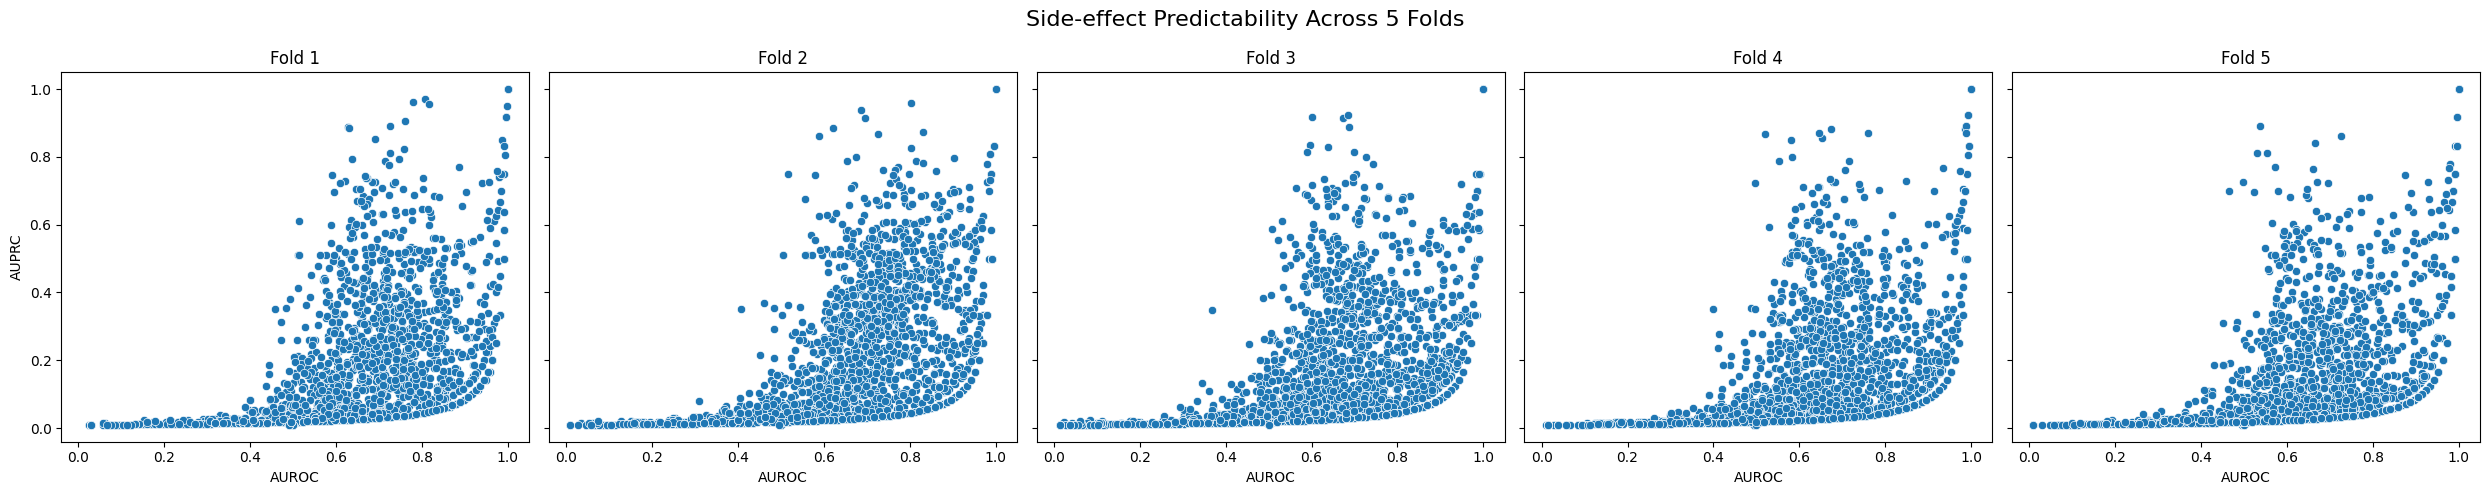

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)

for i, fold_num in enumerate([1, 2, 3, 4, 5]):

    fold_data = results_df[
        results_df["fold"] == fold_num
    ]

    sns.scatterplot(
        data=fold_data,
        x="AUC_ROC",
        y="AUPRC",
        ax=axes[i]
    )

    axes[i].set_title(f"Fold {fold_num}")

    axes[i].set_xlabel("AUROC")
    axes[i].set_ylabel("AUPRC")

plt.suptitle(
    "Side-effect Predictability Across 5 Folds",
    fontsize=16
)

plt.tight_layout()

plt.show()

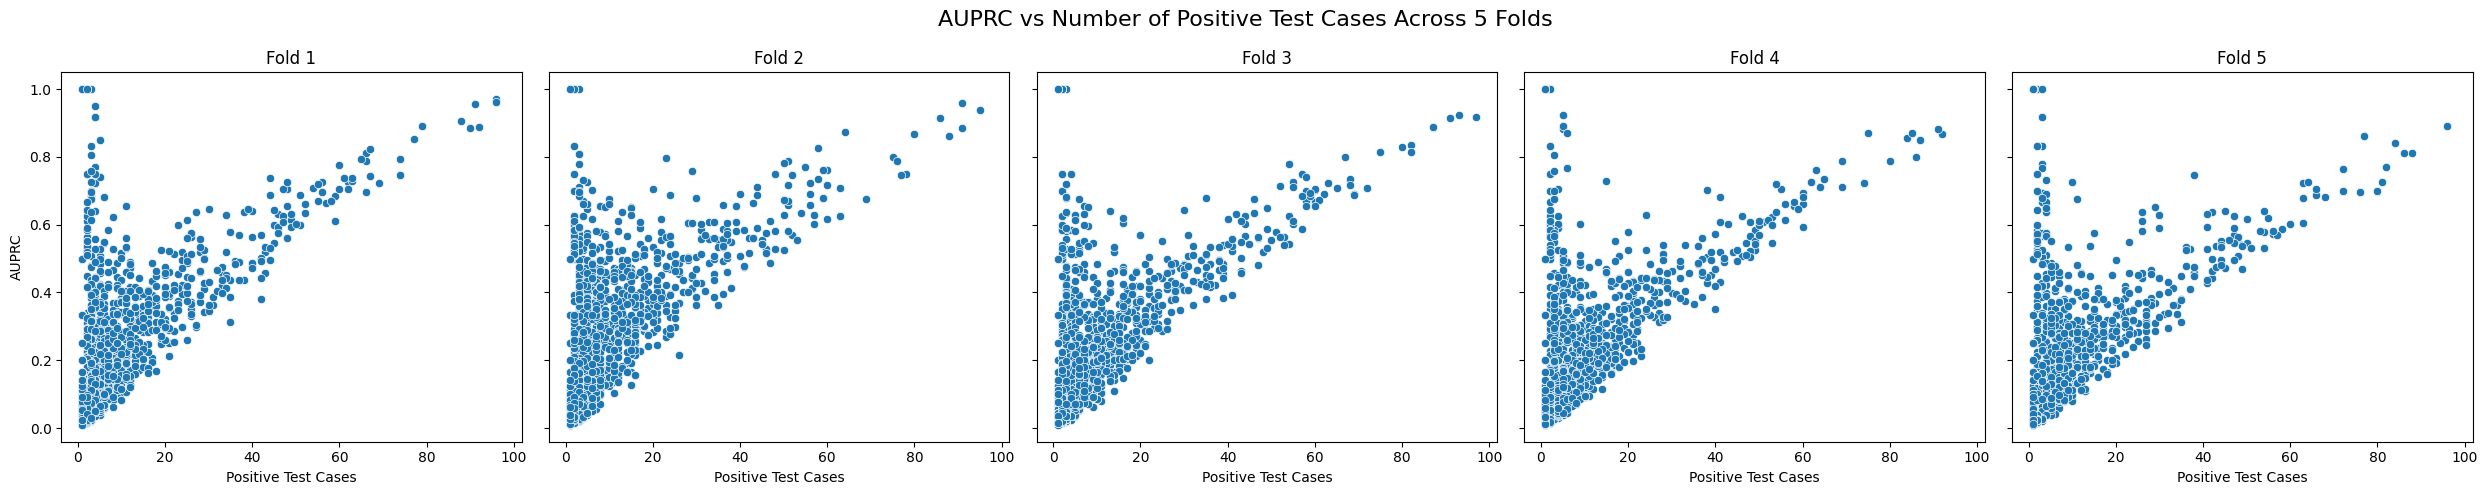

In [ ]:
# Create prevalence column
results_df["test_prevalence"] = (
    results_df["TP"] + results_df["FN"]
)

# SIDE-BY-SIDE SCATTER PLOTS FOR EACH FOLD
fig, axes = plt.subplots(
    1, 5,
    figsize=(25, 5),
    sharex=True,
    sharey=True
)

for i, fold_num in enumerate([1, 2, 3, 4, 5]):

    fold_data = results_df[
        results_df["fold"] == fold_num
    ]

    sns.scatterplot(
        data=fold_data,
        x="test_prevalence",
        y="AUPRC",
        ax=axes[i]
    )

    axes[i].set_title(f"Fold {fold_num}")

    axes[i].set_xlabel("Positive Test Cases")
    axes[i].set_ylabel("AUPRC")

plt.suptitle(
    "AUPRC vs Number of Positive Test Cases Across 5 Folds",
    fontsize=16
)

plt.tight_layout()

plt.show()

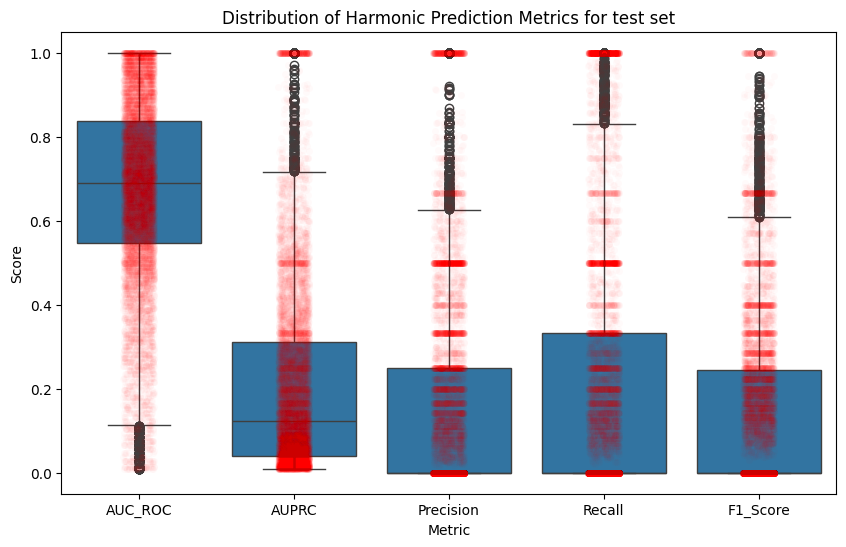

In [ ]:
# Select metrics
plot_df = results_df[[
    "AUC_ROC",
    "AUPRC",
    "Precision",
    "Recall",
    "F1_Score"
]]

# Convert wide → long format
plot_df = plot_df.melt(
    var_name="Metric",
    value_name="Score"
)

# Figure
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(
    data=plot_df,
    x="Metric",
    y="Score"
)

# Stripplot
sns.stripplot(
    data=plot_df,
    x="Metric",
    y="Score",
    color="red",
    alpha=0.02,
    jitter=True
)

# Title
plt.title("Distribution of Harmonic Prediction Metrics for test set")

# Rotate labels
#plt.xticks(rotation=30)

plt.show()

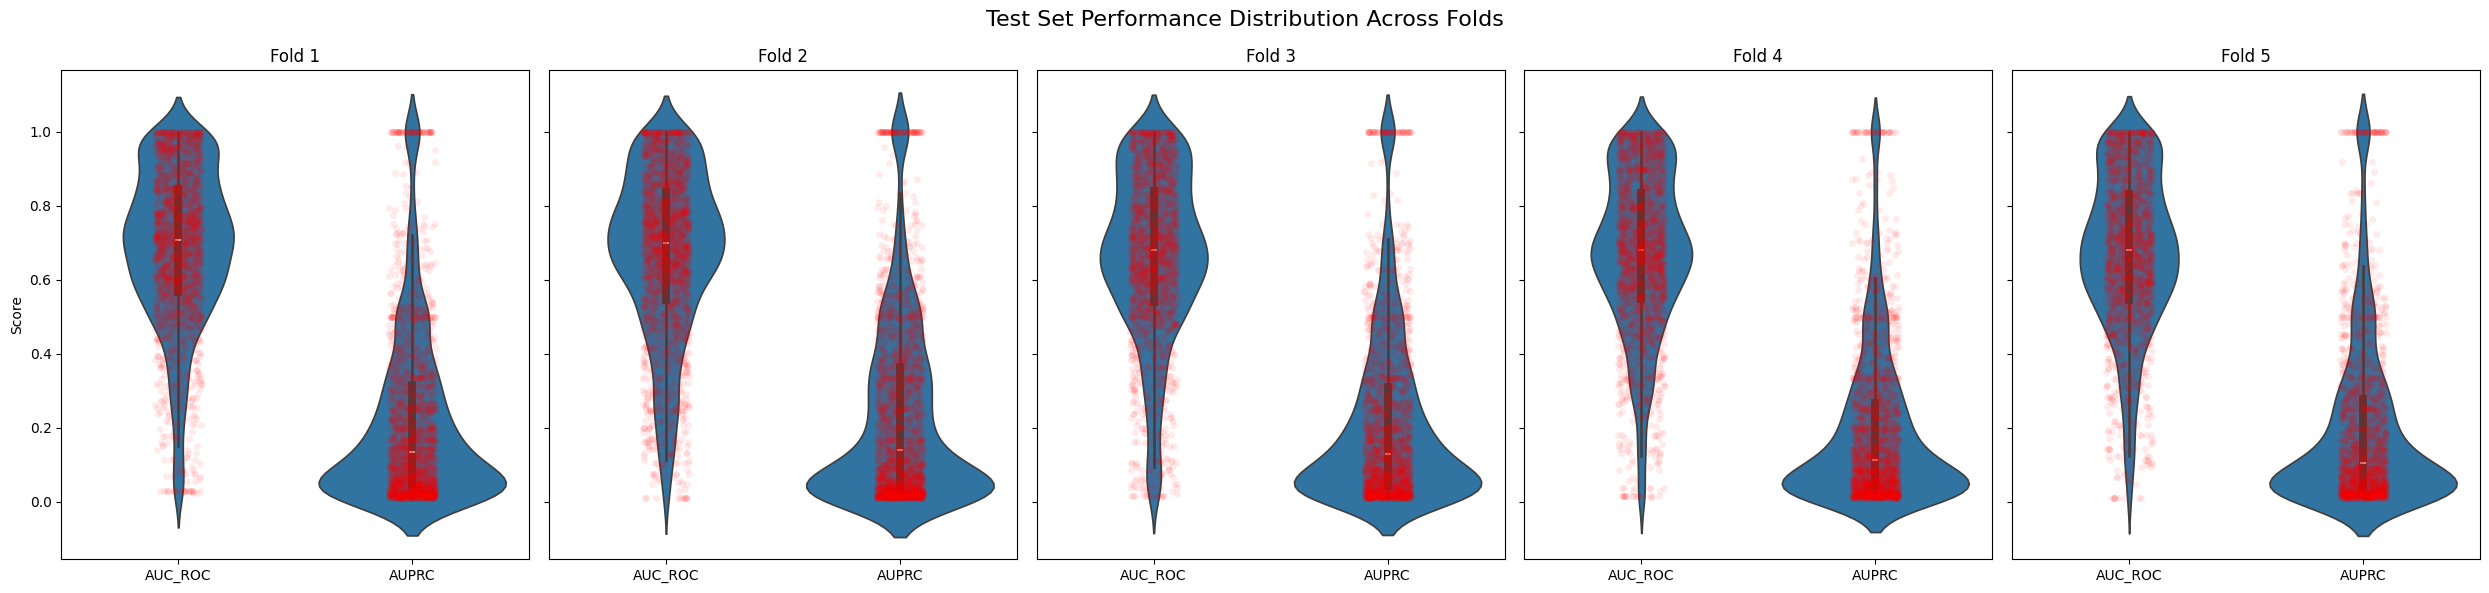

In [ ]:
# VIOLIN + STRIP PLOT FOR EACH FOLD
fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharey=True)

for i, fold_num in enumerate([1, 2, 3, 4, 5]):

    fold_df = results_df[results_df["fold"] == fold_num]

    plot_df = fold_df[[
        "AUC_ROC",
        "AUPRC"
    ]].melt(
        var_name="Metric",
        value_name="Score"
    )

    sns.violinplot(
        data=plot_df,
        x="Metric",
        y="Score",
        inner="box",
        ax=axes[i]
    )

    sns.stripplot(
        data=plot_df,
        x="Metric",
        y="Score",
        color="red",
        alpha=0.08,
        jitter=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Fold {fold_num}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Score" if i == 0 else "")

plt.suptitle("Test Set Performance Distribution Across Folds", fontsize=16)
plt.tight_layout()
plt.show()

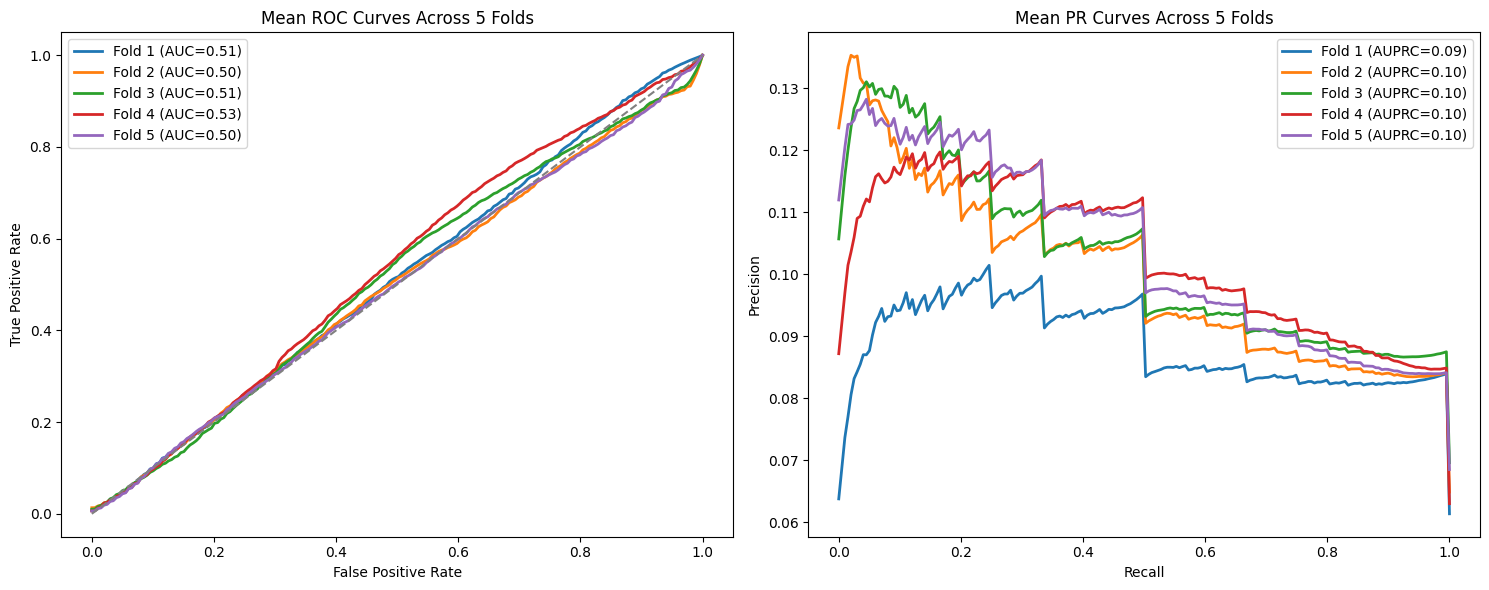

In [ ]:
W = drug_gene_sim.to_numpy(dtype=float)
side_effects_to_use = results_df["side_effect"].drop_duplicates().tolist()

roc_grid = np.linspace(0, 1, 200)
pr_grid = np.linspace(0, 1, 200)

kf = KFold(n_splits=5, shuffle=True, random_state=27)

fold_curves = {}

for fold_num, (train_idx, test_idx) in enumerate(kf.split(common_drugs), start=1):

    fold_tprs = []
    fold_precs = []
    fold_aucs = []
    fold_auprcs = []

    for side_effect_name in side_effects_to_use:

        y = drugs_se[side_effect_name].to_numpy(dtype=float)

        y_true_test = y[test_idx]

        # skip invalid folds for this side effect
        if y[test_idx].sum() == 0 or y[test_idx].sum() == len(test_idx):
            continue

        if len(np.unique(y_true_test)) < 2:
            continue

        # harmonic prediction scores
        scores = harmonic_prediction(W, y, train_idx)

        y_score_test = scores[test_idx]

        # ROC
        fpr_te, tpr_te, _ = roc_curve(y_true_test, y_score_test)

        # PR
        prec_te, rec_te, _ = precision_recall_curve(y_true_test, y_score_test)

        # Interpolate to common grids
        fold_tprs.append(np.interp(roc_grid, fpr_te, tpr_te))
        fold_precs.append(np.interp(pr_grid, rec_te[::-1], prec_te[::-1]))

        # Store fold-level summary scores
        fold_aucs.append(auc(fpr_te, tpr_te))
        fold_auprcs.append(average_precision_score(y_true_test, y_score_test))

    if len(fold_tprs) == 0:
        continue

    fold_curves[fold_num] = {
        "mean_tpr": np.mean(fold_tprs, axis=0),
        "std_tpr": np.std(fold_tprs, axis=0),
        "mean_prec": np.mean(fold_precs, axis=0),
        "std_prec": np.std(fold_precs, axis=0),
        "mean_auc": float(np.mean(fold_aucs)),
        "mean_auprc": float(np.mean(fold_auprcs))
    }


# PLOT ALL FOLDS ON THE SAME GRAPH


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
for fold_num, data in fold_curves.items():
    axes[0].plot(
        roc_grid,
        data["mean_tpr"],
        linewidth=2,
        label=f"Fold {fold_num} (AUC={data['mean_auc']:.2f})"
    )

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Mean ROC Curves Across 5 Folds")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR curves
for fold_num, data in fold_curves.items():
    axes[1].plot(
        pr_grid,
        data["mean_prec"],
        linewidth=2,
        label=f"Fold {fold_num} (AUPRC={data['mean_auprc']:.2f})"
    )

axes[1].set_title("Mean PR Curves Across 5 Folds")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

main file ends above.

**this is experimental to get access of desired adr, associated drugs, genes and respective weighted similarity score.**

Predicted ADR (DERMATITIS) → Associated Drugs → Associated Genes → Similarity Strength

In [ ]:
ranked_se_interpretor = common_df[  # Getting all selected se drugs
    common_df["associated_side_effects"]
    .apply(lambda x: "BALANITIS CANDIDA" in str(x))
].copy()


ranked_se_interpretor["mean_drug_se_score"] = ( #drug_se_similarity_score is a list, converting it into single score
    ranked_se_interpretor["drug_se_similarity_scores"]
    .apply(lambda x: np.mean(x) if isinstance(x, list) else x)
)

se_ranked = (  #rank drugs
    ranked_se_interpretor
    .sort_values(
        "mean_drug_se_score",
        ascending=False
    )
)

se_ranked_final = se_ranked[
    [
        "drug_name",
        "associated_genes",
        "mean_drug_se_score"
    ]
]
se_ranked_final.head()


,drug_name,associated_genes,mean_drug_se_score
73,CANAGLIFLOZIN,"[SLC5A1, SLC5A4]",0.312057
122,DAPAGLIFLOZIN,"[SLC5A1, SLC5A2, SLC5A4]",0.312057


In [ ]:
from collections import Counter

gene_counter = Counter()

for genes in se_ranked_final["associated_genes"]:

    if isinstance(genes, list):
        gene_counter.update(genes)

gene_freq_df = pd.DataFrame(
    gene_counter.items(),
    columns=["Gene", "Frequency"]
)

gene_freq_df = gene_freq_df.sort_values(
    "Frequency",
    ascending=False
)

gene_freq_df.head(1000)

,Gene,Frequency
0,SLC5A1,2
1,SLC5A4,2
2,SLC5A2,1


drug and gene extraction for kegg analysis

In [ ]:
top10_adrs = paper_table.head(15)["side_effect"]
bottom10_adrs = paper_table.tail(12)["side_effect"]
top10_adrs.head(15)
#bottom10_adrs.head(12)

,side_effect
0,CONTACT LENS INTOLERANCE
1,NODAL BLOCK
2,COMPULSIONS
3,NECROTIZING ENTEROCOLITIS
4,NECROTISING ENTEROCOLITIS NEONATAL
5,NECROTISING COLITIS
6,ORAL PRURITUS
7,OESTROGENIC EFFECT
8,GENITAL INFECTION FUNGAL
9,GENITAL DISCHARGE


In [ ]:
top10_adrs.head(15)

,side_effect
0,CONTACT LENS INTOLERANCE
1,NODAL BLOCK
2,COMPULSIONS
3,NECROTIZING ENTEROCOLITIS
4,NECROTISING ENTEROCOLITIS NEONATAL
5,NECROTISING COLITIS
6,ORAL PRURITUS
7,OESTROGENIC EFFECT
8,GENITAL INFECTION FUNGAL
9,GENITAL DISCHARGE


In [ ]:
top_drugs = set()

for adr in top10_adrs:
    drugs = drugs_se.index[drugs_se[adr] == 1]
    top_drugs.update(drugs)


bottom_drugs = set()

for adr in bottom10_adrs:
    drugs = drugs_se.index[drugs_se[adr] == 1]
    bottom_drugs.update(drugs)

In [ ]:
top_genes = set()

for drug in top_drugs:

    if drug in drug_gene.index:

        genes = drug_gene.columns[
            drug_gene.loc[drug] == 1
        ]

        top_genes.update(genes)


bottom_genes = set()

for drug in bottom_drugs:

    if drug in drug_gene.index:

        genes = drug_gene.columns[
            drug_gene.loc[drug] == 1
        ]

        bottom_genes.update(genes)

In [ ]:
pd.Series(list(top_genes)).to_csv(
    "top10_predictable_genes.txt",
    index=False,
    header=False
)

pd.Series(list(bottom_genes)).to_csv(
    "bottom10_predictable_genes.txt",
    index=False,
    header=False
)

Baseline testing

In [ ]:
def knn_baseline(W, drug_se_matrix, common_drugs, k=10, n_splits=5, seed=27):
    Y = drug_se_matrix.to_numpy(dtype=int)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    results = []
    for fold, (train_idx, test_idx) in enumerate(kf.split(common_drugs), start=1):
        sims = W[np.ix_(test_idx, train_idx)]
        nn_idx = np.argsort(-sims, axis=1)[:, :k]

        for si, side_effect in enumerate(drug_se_matrix.columns):
            y = Y[:, si]
            y_test = y[test_idx]

            if y[train_idx].sum() == 0 or y_test.sum() == 0:
                continue
            if len(np.unique(y_test)) < 2:
                continue

            neigh_labels = y[train_idx][nn_idx]        # (n_test, k)
            y_score = neigh_labels.mean(axis=1)
            y_pred = (y_score >= 0.5).astype(int)

            auroc = roc_auc_score(y_test, y_score)
            auprc = average_precision_score(y_test, y_score)
            precision = precision_score(y_test, y_pred, zero_division=0)
            recall = recall_score(y_test, y_pred, zero_division=0)
            f1 = f1_score(y_test, y_pred, zero_division=0)
            accuracy = accuracy_score(y_test, y_pred)
            tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
            specificity = tn / (tn + fp + 1e-12)

            results.append({
                "fold": fold, "side_effect": side_effect,
                "AUC_ROC": auroc, "AUPRC": auprc,
                "Precision": precision, "Recall": recall, "F1_Score": f1,
                "Specificity": specificity, "Accuracy": accuracy,
            })

    return pd.DataFrame(results)

In [ ]:
baseline_results = {}

for k in [5, 10, 15, 20]:
    print(f"Running k-NN baseline (k={k})...")
    df_k = knn_baseline(W, drug_se_matrix, common_drugs, k=k, n_splits=5, seed=27)
    baseline_results[k] = df_k
    print(f"  Mean AUROC: {df_k['AUC_ROC'].mean():.4f}, Mean AUPRC: {df_k['AUPRC'].mean():.4f}")

# pick the k that performed best on AUPRC
best_k = max(baseline_results, key=lambda k: baseline_results[k]["AUPRC"].mean())
baseline_results_df = baseline_results[best_k]
print(f"\nUsing k={best_k} as the reported baseline")

Running k-NN baseline (k=5)...
  Mean AUROC: 0.6078, Mean AUPRC: 0.1654
Running k-NN baseline (k=10)...
  Mean AUROC: 0.6262, Mean AUPRC: 0.1697
Running k-NN baseline (k=15)...
  Mean AUROC: 0.6264, Mean AUPRC: 0.1644
Running k-NN baseline (k=20)...
  Mean AUROC: 0.6255, Mean AUPRC: 0.1597

Using k=10 as the reported baseline


In [ ]:
baseline_summary = (
    baseline_results_df[["AUC_ROC", "AUPRC", "Precision", "Recall", "F1_Score", "Specificity", "Accuracy"]]
    .mean()
)

comparison = pd.DataFrame({
    "Harmonic Propagation": overall_summary,
    f"k-NN Baseline (k={best_k})": baseline_summary,
})
comparison["Difference"] = comparison["Harmonic Propagation"] - comparison[f"k-NN Baseline (k={best_k})"]
comparison

,Harmonic Propagation,k-NN Baseline (k=10),Difference
AUC_ROC,0.670215,0.626160,0.044054
AUPRC,0.210628,0.169726,0.040902
Precision,0.164252,0.106158,0.058094
Recall,0.205457,0.055959,0.149498
F1_Score,0.143605,0.064218,0.079387
Specificity,0.924478,0.976115,-0.051637
Accuracy,0.897635,0.940504,-0.042869


In [ ]:
h_auroc, h_auprc = overall_summary["AUC_ROC"], overall_summary["AUPRC"]
b_auroc, b_auprc = baseline_summary["AUC_ROC"], baseline_summary["AUPRC"]

verdict = "outperforms" if h_auprc > b_auprc + 0.01 else \
          "performs comparably to" if abs(h_auprc - b_auprc) <= 0.01 else \
          "does not clearly outperform"

print(f"Baseline (k={best_k}): AUROC={b_auroc:.3f}, AUPRC={b_auprc:.3f}")
print(f"Harmonic: AUROC={h_auroc:.3f}, AUPRC={h_auprc:.3f}")
print(f"\nSentence: '...indicating that graph-based label propagation {verdict} "
      f"a simple similarity-based classifier on this dataset.'")

Baseline (k=10): AUROC=0.626, AUPRC=0.170
Harmonic: AUROC=0.670, AUPRC=0.211

Sentence: '...indicating that graph-based label propagation outperforms a simple similarity-based classifier on this dataset.'
